In [295]:
import pandas as pd

In [296]:
df_train=pd.read_csv('train.csv')

In [297]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [298]:
df_train.shape

(891, 12)

In [299]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<Axes: >

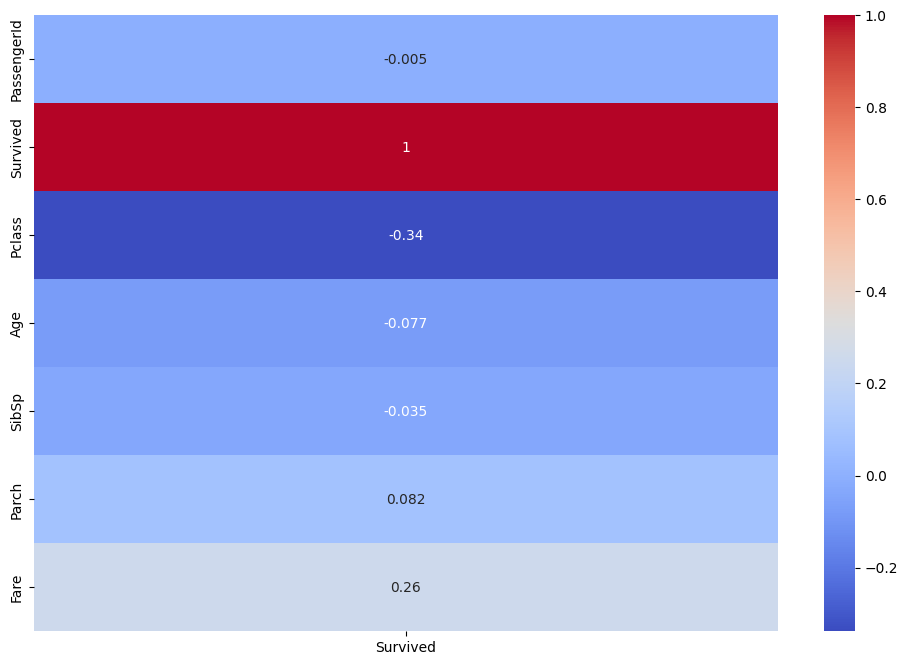

In [300]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
corr=df_train.corr(numeric_only=True)
sns.heatmap(
corr[['Survived']].sort_values(by='Survived',axis=1),
annot=True,
cmap='coolwarm'
)

In [301]:
df_train.drop(columns=['PassengerId','Cabin'])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [302]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.01)  
df=df_train.select_dtypes(exclude='object')
sel.fit(df.drop('Survived', axis=1))

low_var_cols = df.drop('Survived', axis=1).columns[~sel.get_support()]

print("Low variance columns:", low_var_cols)

Low variance columns: Index([], dtype='object')


<Axes: xlabel='Sex', ylabel='count'>

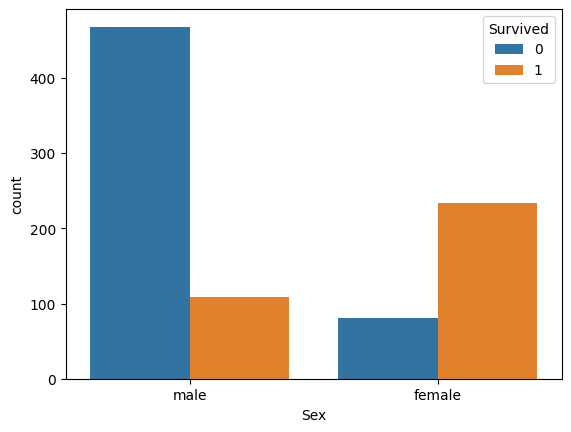

In [303]:
sns.countplot(x='Sex',hue='Survived',data=df_train)

<Axes: xlabel='Pclass', ylabel='count'>

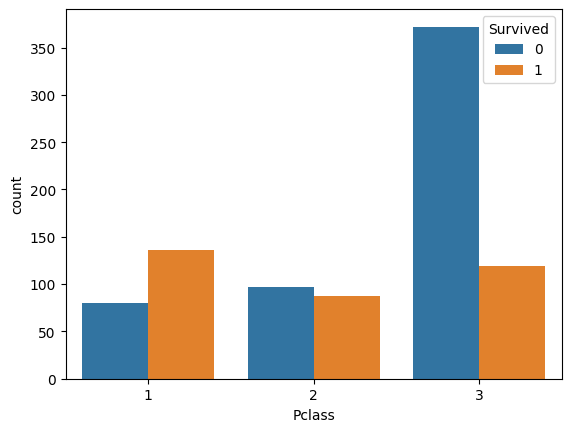

In [304]:
sns.countplot(x=df_train['Pclass'],hue=df_train['Survived'])

In [305]:
X=df_train.drop(columns=['Survived'])
y=df_train['Survived']

In [306]:
from sklearn.pipeline import Pipeline as pip        # pipline without smote
from imblearn.pipeline import Pipeline  #pipline with smote
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [307]:
from imblearn.over_sampling import SMOTE
num_pip = Pipeline([
  ('fill null',SimpleImputer(strategy = 'mean')),  #fill missing value
  ('scale',StandardScaler())   #scale numeric value
])

In [308]:
from sklearn.preprocessing import OneHotEncoder
cat_pip=Pipeline([
    ('fill missing value',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# this step for column tranform 
num = X.select_dtypes(exclude='object').columns # (X not all data) beacause we want to delete target feature
cat = X.select_dtypes(include='object').columns

In [310]:
df=ColumnTransformer([
    ('numeric',num_pip,num),
    ('cat',cat_pip,cat)
])

In [311]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [312]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
models={
    'SVM':SVC(random_state=42),
    'knn':KNeighborsClassifier(),
    'logstic regression':LogisticRegression(random_state=42),
    'ID3':DecisionTreeClassifier(random_state=42),
    'random forest':RandomForestClassifier(random_state=42),
    'XG_boost':XGBClassifier()
} 

In [313]:
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
scores=[]
for mode_nam,mode_per in models.items():
    result=Pipeline([
     ('data',df),
     ('model',mode_per)   
    ])
    result.fit(X_train,y_train)
    y_pred=result.predict(X_test)
    acuuracy=accuracy_score(y_test,y_pred)
    scores.append({"model_name":mode_nam,"score":acuuracy})

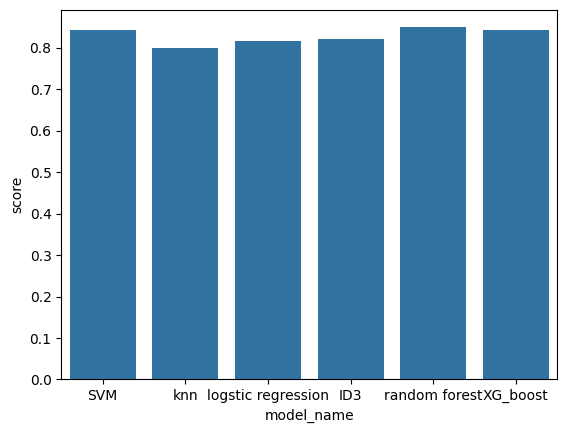

In [314]:
s=pd.DataFrame(scores)
sns.barplot(x=s['model_name'],y=s['score'])
plt.show()

In [315]:
s

,model_name,score
0,SVM,0.843575
1,knn,0.798883
2,logstic regression,0.815642
3,ID3,0.821229
4,random forest,0.849162
5,XG_boost,0.843575


In [322]:
md=Pipeline([
    ('data',df),
    ('model',RandomForestClassifier(random_state=42))
    ])
param={
    'model__n_estimators':[100,200,500],
    'model__max_depth':[None,10,20,30]
}
grid=GridSearchCV(
    estimator=md,
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train,y_train)
print("Best parameters:", grid.best_params_)
print("Best score:",grid.best_score_)

Best parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Best score: 0.8104205653501427


In [323]:
mod = grid.best_estimator_

In [324]:
mod

Pipeline(steps=[('data',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('fill null',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('fill '
                                                                   'missing '
                                                                   'value',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [325]:
mod.fit(X_train,y_train)
ypred=mod.predict(X_test)
acc=accuracy_score(y_test,y_pred)
acc

0.8435754189944135

classification report               precision    recall  f1-score   support

           0       0.87      0.88      0.87       110
           1       0.81      0.78      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

ConfusionMatrix <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001A356080C20>


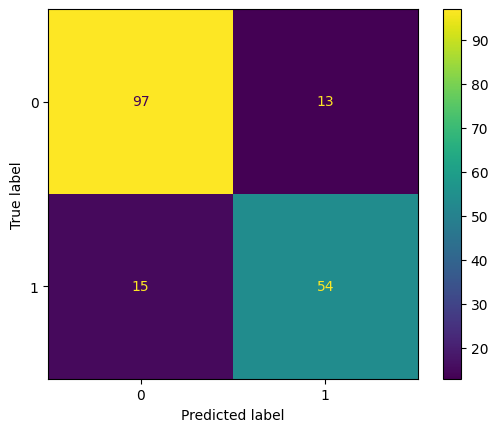

In [326]:
print("classification report",classification_report(y_test,y_pred))
print("ConfusionMatrix",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [329]:
va=mod.predict(X_train)
acc_train=accuracy_score(y_train,va)
acc_train

1.0